<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB
Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Rock         44
Electric     44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy       

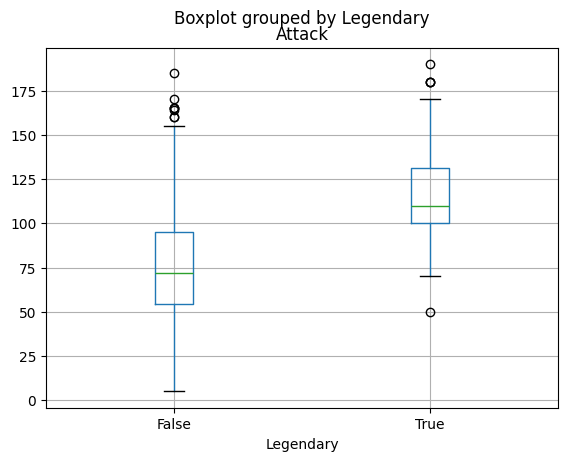

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   #           800 non-null    int64   
 1   Name        799 non-null    object  
 2   Type 1      800 non-null    category
 3   Type 2      414 non-null    object  
 4   HP          800 non-null    int64   
 5   Attack      800 non-null    int64   
 6   Defense     800 non-null    int64   
 7   Sp. Atk     800 non-null    int64   
 8   Sp. Def     800 non-null    int64   
 9   Speed       800 non-null    float64 
 10  Generation  800 non-null    int64   
 11  Legendary   800 non-null    bool    
dtypes: bool(1), category(1), float64(1), int64(7), object(2)
memory usage: 64.9+ KB


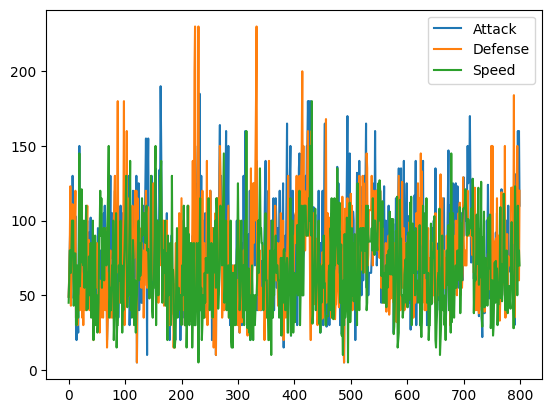

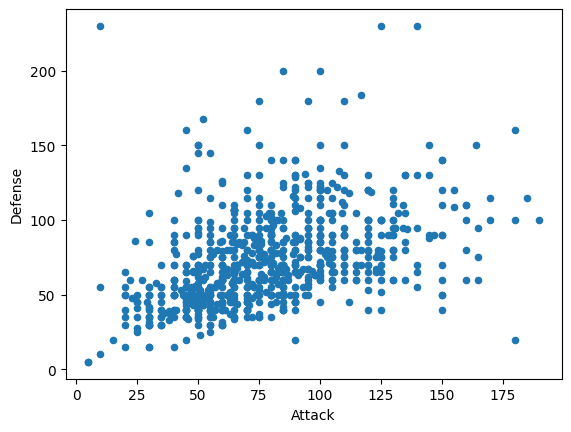

<class 'str'>
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
#                      5
Name          Charmander
Type 1              Fire
Type 2             empty
HP                    39
Attack                52
Defense               43
Sp. Atk               60
Sp. Def               50
Speed               65.0
Generation             1
Legendary          False
Name: 1993-03-16 00:00:00, dtype: object
            #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  \
date                                                                        
1992-03-10  3       Venusaur  Grass  Poison  80      82       83      100   
1993-03-15  4  Mega Venusaur  Grass  Poison  80     100      123      122   
1993-03-16  5     Charmander   Fire   empty  39      52       43       60   

            Sp. Def  Speed  Generation  Legendary  
date                                               
1992-03-10      100   80.0           1      False  
1993-03-15      120   80.0           1      False

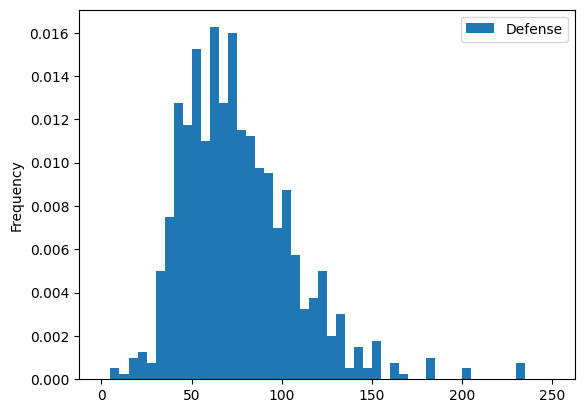

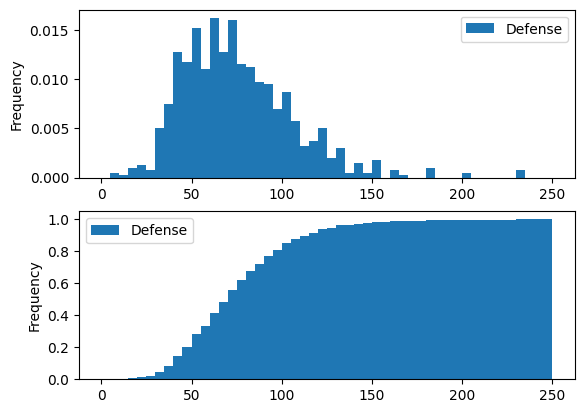

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from google.colab import files
uploaded = files.upload()
data = pd.read_csv('pokemon.csv')

data.head()
data.tail()
data.columns
data.shape
data.info()

print(data['Type 1'].value_counts(dropna =False))
data.describe()
data.boxplot(column ='Attack',by = 'Legendary')
plt.show()

data_new = data.head()
data_new
melted = pd.melt(frame=data_new,id_vars = 'Name', value_vars= ['Attack','Defense'])
melted

melted.pivot(index = 'Name', columns = 'variable',values='value')
melted

data1 = data.head()
data2 = data.tail()
conc_data_row = pd.concat([data1,data2],axis =0,ignore_index =True)
conc_data_row

data1 = data['Attack'].head()
data2 = data['Defense'].head()
conc_data_col = pd.concat([data1,data2],axis =1) # axis = 1 : adds dataframes in column
conc_data_col

data.dtypes
data['Type 1'] = data['Type 1'].astype('category')
data['Speed'] = data['Speed'].astype('float')
data.dtypes

data.info()
data["Type 2"].value_counts(dropna =False)
data1=data
data1["Type 2"].dropna(inplace = True)
#assert  data['Type 2'].notnull().all()
data["Type 2"].fillna('empty',inplace = True)
assert  data['Type 2'].notnull().all()

country = ["Spain","France"]
population = ["11","12"]
list_label = ["country","population"]
list_col = [country,population]
zipped = list(zip(list_label,list_col))
data_dict = dict(zipped)

df = pd.DataFrame(data_dict)
df

df["income"] = 0
df

data1 = data.loc[:,["Attack","Defense","Speed"]]
data1.plot()
data1.plot(kind = "scatter",x="Attack",y = "Defense")
plt.show()
data1.plot(kind = "hist",y = "Defense",bins = 50,range= (0,250),density = True)

fig, axes = plt.subplots(nrows=2,ncols=1)
data1.plot(kind = "hist",y = "Defense",bins = 50,range= (0,250),density = True,ax = axes[0])
data1.plot(kind = "hist",y = "Defense",bins = 50,range= (0,250),density = True,ax = axes[1],cumulative = True)
plt.savefig('graph.png')
plt

time_list = ["1992-03-08","1992-04-12"]
print(type(time_list[1])) # As you can see date is string
datetime_object = pd.to_datetime(time_list)
print(type(datetime_object))

warnings.filterwarnings("ignore")
data2 = data.head()
date_list = ["1992-01-10","1992-02-10","1992-03-10","1993-03-15","1993-03-16"]
datetime_object = pd.to_datetime(date_list)
data2["date"] = datetime_object
data2= data2.set_index("date")
data2
print(data2.loc["1993-03-16"])
print(data2.loc["1992-03-10":"1993-03-16"])

#data2.resample("A").mean()
#data2.resample("M").mean()
